In [1]:
from roboflow import Roboflow
import os
import shutil
import random
import yaml

rf = Roboflow(api_key="9X8ClVkM9agUJAH3hcAN")
project = rf.workspace("hard-drive").project("hdd_local_sniper")
version = project.version(3)
dataset = version.download("yolov8")
                

DATA_PATH = dataset.location
OUTPUT_DIR = "dataset_rfdetr_box_640"

# 2. Create directory structure
for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, 'labels'), exist_ok=True)

images_dir = os.path.join(DATA_PATH, "train", "images")
labels_dir = os.path.join(DATA_PATH, "train", "labels")

# 3. Shuffle and split (80% Train, 10% Val, 10% Test)
images = [f for f in os.listdir(images_dir) if f.endswith('.jpg')]
random.seed(42)
random.shuffle(images)

train_idx, val_idx = int(len(images) * 0.8), int(len(images) * 0.9)
splits = {'train': images[:train_idx], 'valid': images[train_idx:val_idx], 'test': images[val_idx:]}

# 4. Safely move Images and CLEAN Labels (Strip Keypoints)
for split_name, img_list in splits.items():
    for img_name in img_list:
        # Copy Image
        shutil.copy(os.path.join(images_dir, img_name), os.path.join(OUTPUT_DIR, split_name, 'images', img_name))
        
        # Clean and Copy Label
        label_name = img_name.replace('.jpg', '.txt')
        label_src = os.path.join(labels_dir, label_name)
        label_dest = os.path.join(OUTPUT_DIR, split_name, 'labels', label_name)
        
        if os.path.exists(label_src):
            with open(label_src, 'r') as f_in:
                lines = f_in.readlines()
            
            cleaned_lines = []
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    # Keep ONLY the first 5 elements (class, cx, cy, w, h)
                    # This drops the keypoints for screws/tools, but leaves the hole class perfectly intact
                    cleaned_lines.append(" ".join(parts[:5]))
            
            with open(label_dest, 'w') as f_out:
                f_out.write("\n".join(cleaned_lines) + "\n")

# 5. Fix data.yaml paths for RF-DETR
with open(os.path.join(DATA_PATH, 'data.yaml'), 'r') as f:
    data_yaml = yaml.safe_load(f)

data_yaml['train'] = 'train/images'
data_yaml['val'] = 'valid/images'
data_yaml['test'] = 'test/images'

with open(os.path.join(OUTPUT_DIR, 'data.yaml'), 'w') as f:
    yaml.dump(data_yaml, f)

print(f"✅ Dataset split and cleaned! Keypoints stripped. data.yaml placed in {OUTPUT_DIR}/")

loading Roboflow workspace...
loading Roboflow project...
✅ Dataset split and cleaned! Keypoints stripped. data.yaml placed in dataset_rfdetr_box_640/


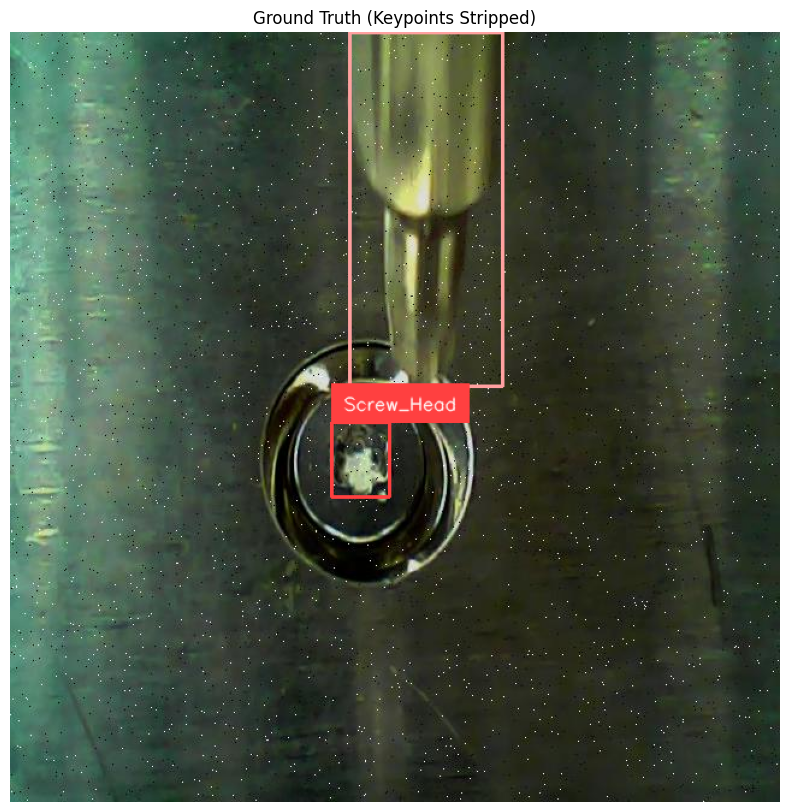

In [2]:
import supervision as sv
import cv2
import matplotlib.pyplot as plt

# Load dataset into Supervision to verify the bounding boxes are clean
dataset = sv.DetectionDataset.from_yolo(
    images_directory_path=os.path.join(OUTPUT_DIR, 'train', 'images'),
    annotations_directory_path=os.path.join(OUTPUT_DIR, 'train', 'labels'),
    data_yaml_path=os.path.join(OUTPUT_DIR, 'data.yaml')
)

image_name, image, annotations = dataset[0]

# Setup Box Annotator
box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator()

with open(os.path.join(OUTPUT_DIR, 'data.yaml'), 'r') as f:
    classes = yaml.safe_load(f)['names']

labels = [classes[class_id] for class_id in annotations.class_id]

# Apply Annotations
annotated_image = box_annotator.annotate(scene=image.copy(), detections=annotations)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=annotations, labels=labels)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Ground Truth (Keypoints Stripped)")
plt.show()

In [3]:
from rfdetr import RFDETRSmall

# Initialize the pure detection variant
model = RFDETRSmall()
RUN_DIR = "runs/train/rfdetr_box_640"

# Train the model
model.train(
    dataset_dir=OUTPUT_DIR,
    output_dir=RUN_DIR,
    epochs=100,
    batch_size=4,          # Safe for 8GB VRAM
    resolution=640         # Inference resolution matches training
)

[2026-03-11 15:18:34] [INFO] rf-detr - File rf-detr-small.pth already exists with correct MD5 hash.


[2026-03-11 15:18:34] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-11 15:18:34] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-11 15:18:34] [INFO] rf-detr - Loading pretrain weights


[2026-03-11 15:18:34] [WARNING] rf-detr - Reinitializing your detection head with 4 classes.
[2026-03-11 15:18:34] [WARNING] rf-detr - Unable to initialize TensorBoard. Logging is turned off for this session. Run 'pip install tensorboard' to enable logging.


[2026-03-11 15:18:34] [INFO] rf-detr - Not using distributed mode
[2026-03-11 15:18:35] [INFO] rf-detr - git:
  sha: fd57ef1c67a83be3f2a2e0d4be5c81902956bfa4, status: has uncommitted changes, branch: devel_agent_v4

[2026-03-11 15:18:35] [INFO] rf-detr - Namespace(num_classes=4, grad_accum_steps=4, print_freq=10, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=100, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-small.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[3, 6, 9, 12], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_

...

[2026-03-11 17:28:51] [INFO] rf-detr - Epoch: [98/100]  [ 0/95]  eta: 0:02:01  lr: 0.000100  class_error: 0.00  loss: 1.0528 (1.0528)  loss_ce: 0.1463 (0.1463)  loss_bbox: 0.0239 (0.0239)  loss_giou: 0.0681 (0.0681)  loss_ce_0: 0.1527 (0.1527)  loss_bbox_0: 0.0252 (0.0252)  loss_giou_0: 0.0724 (0.0724)  loss_ce_1: 0.1497 (0.1497)  loss_bbox_1: 0.0245 (0.0245)  loss_giou_1: 0.0709 (0.0709)  loss_ce_enc: 0.1882 (0.1882)  loss_bbox_enc: 0.0419 (0.0419)  loss_giou_enc: 0.0891 (0.0891)  loss_ce_unscaled: 0.1463 (0.1463)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled: 0.0048 (0.0048)  loss_giou_unscaled: 0.0340 (0.0340)  cardinality_error_unscaled: 3036.5000 (3036.5000)  loss_ce_0_unscaled: 0.1527 (0.1527)  loss_bbox_0_unscaled: 0.0050 (0.0050)  loss_giou_0_unscaled: 0.0362 (0.0362)  cardinality_error_0_unscaled: 1784.5000 (1784.5000)  loss_ce_1_unscaled: 0.1497 (0.1497)  loss_bbox_1_unscaled: 0.0049 (0.0049)  loss_giou_1_unscaled: 0.0354 (0.0354)  cardinality_error_1_unscaled: 2

[2026-03-11 17:30:09] [INFO] rf-detr - Epoch: [99/100]  [ 0/95]  eta: 0:02:11  lr: 0.000100  class_error: 0.00  loss: 0.7784 (0.7784)  loss_ce: 0.1043 (0.1043)  loss_bbox: 0.0173 (0.0173)  loss_giou: 0.0392 (0.0392)  loss_ce_0: 0.0982 (0.0982)  loss_bbox_0: 0.0177 (0.0177)  loss_giou_0: 0.0349 (0.0349)  loss_ce_1: 0.1011 (0.1011)  loss_bbox_1: 0.0166 (0.0166)  loss_giou_1: 0.0377 (0.0377)  loss_ce_enc: 0.1821 (0.1821)  loss_bbox_enc: 0.0441 (0.0441)  loss_giou_enc: 0.0851 (0.0851)  loss_ce_unscaled: 0.1043 (0.1043)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled: 0.0035 (0.0035)  loss_giou_unscaled: 0.0196 (0.0196)  cardinality_error_unscaled: 3228.0000 (3228.0000)  loss_ce_0_unscaled: 0.0982 (0.0982)  loss_bbox_0_unscaled: 0.0035 (0.0035)  loss_giou_0_unscaled: 0.0174 (0.0174)  cardinality_error_0_unscaled: 1853.5000 (1853.5000)  loss_ce_1_unscaled: 0.1011 (0.1011)  loss_bbox_1_unscaled: 0.0033 (0.0033)  loss_giou_1_unscaled: 0.0188 (0.0188)  cardinality_error_1_unscaled: 1

[2026-03-11 17:30:16] [INFO] rf-detr - Epoch: [99/100]  [10/95]  eta: 0:01:01  lr: 0.000100  class_error: 0.00  loss: 1.0926 (1.1313)  loss_ce: 0.1385 (0.1491)  loss_bbox: 0.0210 (0.0217)  loss_giou: 0.0614 (0.0688)  loss_ce_0: 0.1484 (0.1626)  loss_bbox_0: 0.0226 (0.0229)  loss_giou_0: 0.0638 (0.0721)  loss_ce_1: 0.1428 (0.1517)  loss_bbox_1: 0.0213 (0.0221)  loss_giou_1: 0.0601 (0.0691)  loss_ce_enc: 0.2273 (0.2350)  loss_bbox_enc: 0.0441 (0.0422)  loss_giou_enc: 0.1150 (0.1139)  loss_ce_unscaled: 0.1385 (0.1491)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled: 0.0042 (0.0043)  loss_giou_unscaled: 0.0307 (0.0344)  cardinality_error_unscaled: 3361.2500 (3328.4773)  loss_ce_0_unscaled: 0.1484 (0.1626)  loss_bbox_0_unscaled: 0.0045 (0.0046)  loss_giou_0_unscaled: 0.0319 (0.0360)  cardinality_error_0_unscaled: 1661.7500 (1566.1591)  loss_ce_1_unscaled: 0.1428 (0.1517)  loss_bbox_1_unscaled: 0.0043 (0.0044)  loss_giou_1_unscaled: 0.0300 (0.0346)  cardinality_error_1_unscaled: 2

[2026-03-11 17:31:27] [INFO] rf-detr - Epoch: [100/100]  [ 0/95]  eta: 0:01:56  lr: 0.000100  class_error: 0.00  loss: 1.2344 (1.2344)  loss_ce: 0.1762 (0.1762)  loss_bbox: 0.0195 (0.0195)  loss_giou: 0.0869 (0.0869)  loss_ce_0: 0.1819 (0.1819)  loss_bbox_0: 0.0207 (0.0207)  loss_giou_0: 0.0924 (0.0924)  loss_ce_1: 0.1729 (0.1729)  loss_bbox_1: 0.0178 (0.0178)  loss_giou_1: 0.0844 (0.0844)  loss_ce_enc: 0.2253 (0.2253)  loss_bbox_enc: 0.0339 (0.0339)  loss_giou_enc: 0.1227 (0.1227)  loss_ce_unscaled: 0.1762 (0.1762)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled: 0.0039 (0.0039)  loss_giou_unscaled: 0.0435 (0.0435)  cardinality_error_unscaled: 3361.7500 (3361.7500)  loss_ce_0_unscaled: 0.1819 (0.1819)  loss_bbox_0_unscaled: 0.0041 (0.0041)  loss_giou_0_unscaled: 0.0462 (0.0462)  cardinality_error_0_unscaled: 1365.0000 (1365.0000)  loss_ce_1_unscaled: 0.1729 (0.1729)  loss_bbox_1_unscaled: 0.0036 (0.0036)  loss_giou_1_unscaled: 0.0422 (0.0422)  cardinality_error_1_unscaled: 

[2026-03-11 17:31:34] [INFO] rf-detr - Epoch: [100/100]  [10/95]  eta: 0:01:05  lr: 0.000100  class_error: -0.00  loss: 1.2000 (1.2174)  loss_ce: 0.1639 (0.1672)  loss_bbox: 0.0236 (0.0239)  loss_giou: 0.0824 (0.0820)  loss_ce_0: 0.1754 (0.1801)  loss_bbox_0: 0.0266 (0.0248)  loss_giou_0: 0.0844 (0.0829)  loss_ce_1: 0.1678 (0.1688)  loss_bbox_1: 0.0252 (0.0240)  loss_giou_1: 0.0839 (0.0818)  loss_ce_enc: 0.2220 (0.2257)  loss_bbox_enc: 0.0416 (0.0410)  loss_giou_enc: 0.1193 (0.1151)  loss_ce_unscaled: 0.1639 (0.1672)  class_error_unscaled: 0.0000 (-0.0000)  loss_bbox_unscaled: 0.0047 (0.0048)  loss_giou_unscaled: 0.0412 (0.0410)  cardinality_error_unscaled: 3408.0000 (3446.0455)  loss_ce_0_unscaled: 0.1754 (0.1801)  loss_bbox_0_unscaled: 0.0053 (0.0050)  loss_giou_0_unscaled: 0.0422 (0.0415)  cardinality_error_0_unscaled: 1600.2500 (1536.4773)  loss_ce_1_unscaled: 0.1678 (0.1688)  loss_bbox_1_unscaled: 0.0050 (0.0048)  loss_giou_1_unscaled: 0.0420 (0.0409)  cardinality_error_1_unscaled

In [6]:
import json
import pandas as pd
import os

RUN_DIR = "runs/train/rfdetr_box_640"
log_file = os.path.join(RUN_DIR, 'log.txt')

if os.path.exists(log_file):
    records = []
    with open(log_file, 'r') as f:
        for line in f:
            try:
                # RF-DETR writes each epoch's stats as a JSON line
                records.append(json.loads(line.strip()))
            except json.JSONDecodeError:
                continue # Skip non-JSON lines

    df = pd.DataFrame(records)
    
    # In standard DETR architectures, the mAP metrics are stored in a list 
    # under the key 'test_coco_eval_bbox'. The first item is mAP 50-95.
    if 'test_coco_eval_bbox' in df.columns:
        # Extract the first element (mAP 0.5:0.95) from the evaluation array
        best_box_map = df['test_coco_eval_bbox'].dropna().apply(lambda x: x[0]).max()
        print(f"🏆 Best Bounding Box mAP (50-95): {best_box_map:.4f}")
    else:
        # Fallback just in case the keys are named differently
        print("Metrics loaded successfully! Available columns:")
        print(df.columns.tolist())
else:
    print("❌ log.txt file not found. Ensure training completed.")

🏆 Best Bounding Box mAP (50-95): 0.9387


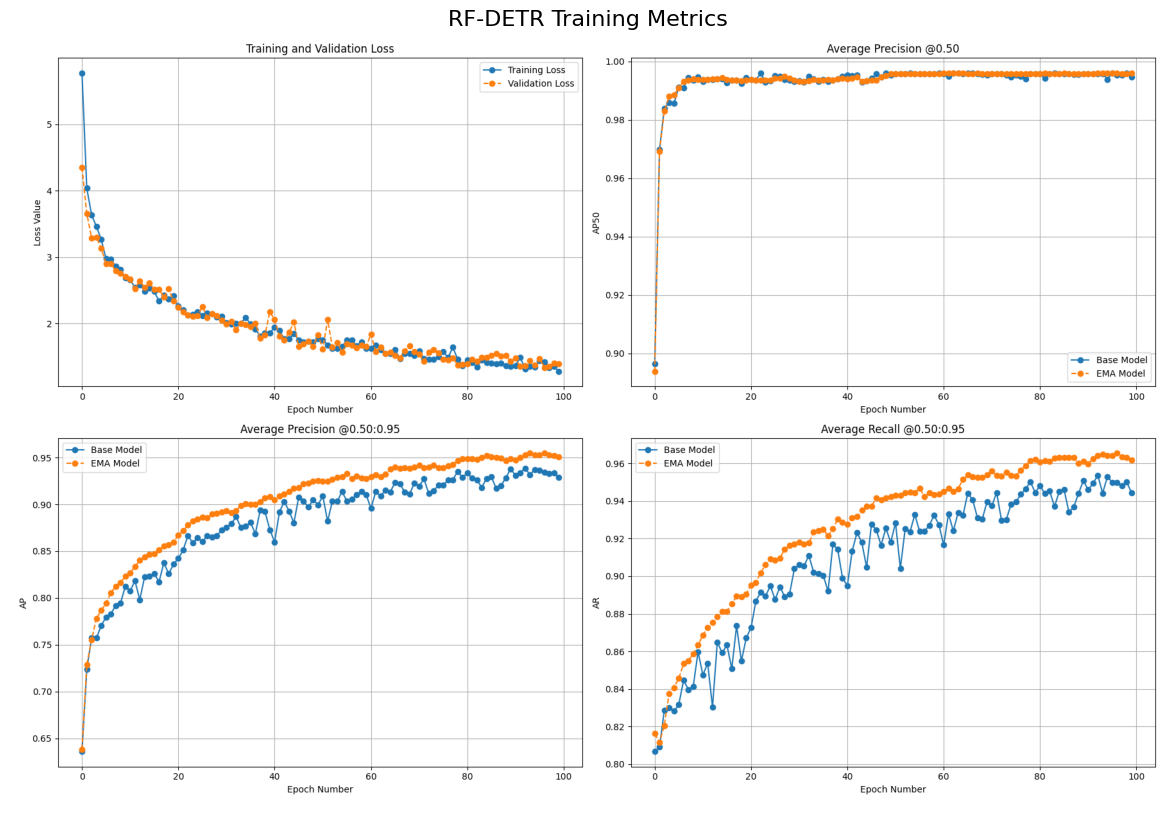

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

RUN_DIR = "runs/train/rfdetr_box_640"
plot_path = os.path.join(RUN_DIR, 'metrics_plot.png')

if os.path.exists(plot_path):
    plt.figure(figsize=(15, 10))
    img = mpimg.imread(plot_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title("RF-DETR Training Metrics", fontsize=16)
    plt.show()
else:
    print(f"⚠️ {plot_path} not found.")

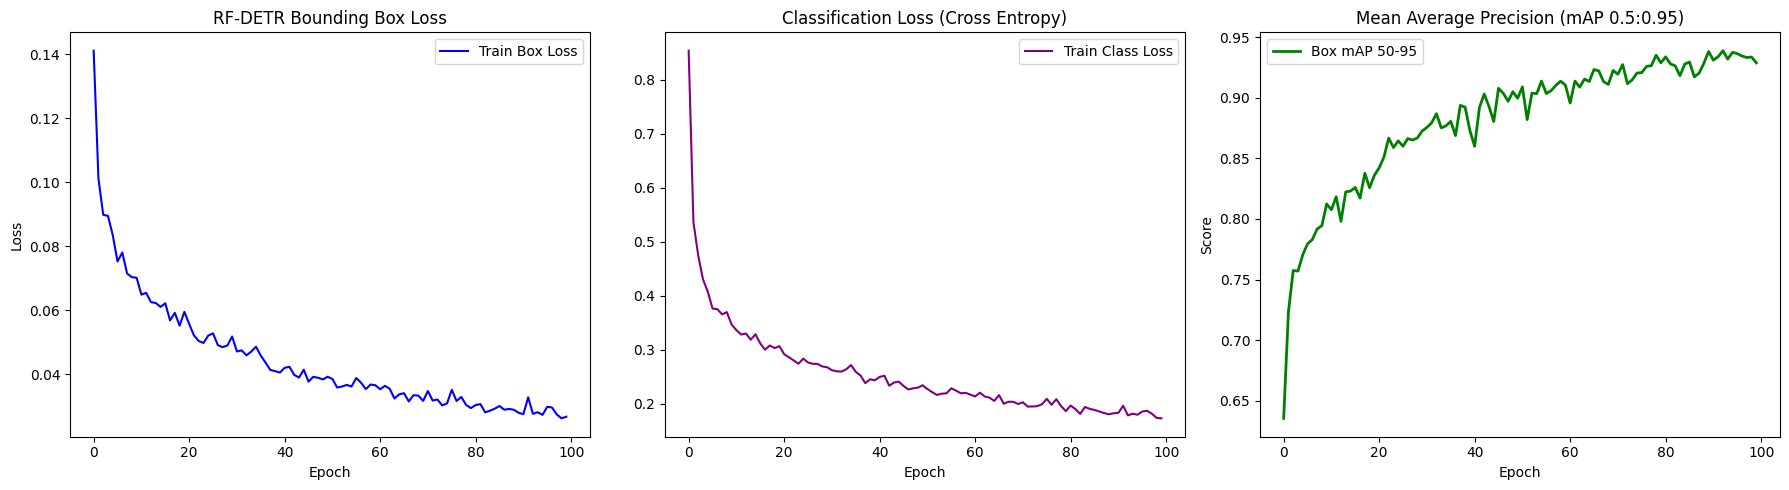

In [8]:
import matplotlib.pyplot as plt

# Ensure the dataframe from the previous log.txt parsing cell exists
if 'df' in locals() and not df.empty:
    plt.figure(figsize=(18, 5))

    # --- 1. Bounding Box Loss ---
    plt.subplot(1, 3, 1)
    if 'train_loss_bbox' in df.columns:
        # DETR logs usually prefix with 'train_'
        plt.plot(df['epoch'], df['train_loss_bbox'], label='Train Box Loss', color='blue')
    plt.title('RF-DETR Bounding Box Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # --- 2. Classification Loss ---
    plt.subplot(1, 3, 2)
    if 'train_loss_ce' in df.columns:
        plt.plot(df['epoch'], df['train_loss_ce'], label='Train Class Loss', color='purple')
    plt.title('Classification Loss (Cross Entropy)')
    plt.xlabel('Epoch')
    plt.legend()

    # --- 3. Bounding Box mAP ---
    plt.subplot(1, 3, 3)
    if 'test_coco_eval_bbox' in df.columns:
        # mAP is stored as an array where index 0 is mAP 50-95.
        # We drop NaNs because evaluation might not happen every single epoch.
        eval_data = df.dropna(subset=['test_coco_eval_bbox'])
        map_scores = eval_data['test_coco_eval_bbox'].apply(lambda x: x[0])
        plt.plot(eval_data['epoch'], map_scores, label='Box mAP 50-95', color='green', linewidth=2)
        
    plt.title('Mean Average Precision (mAP 0.5:0.95)')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("❌ Dataframe 'df' not found. Make sure you ran the Cell 5 code to parse log.txt!")

[2026-03-11 17:40:19] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-11 17:40:19] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-11 17:40:19] [INFO] rf-detr - Loading pretrain weights


[2026-03-11 17:40:20] [WARNING] rf-detr - Reinitializing detection head with 3 classes based on pretrained weights, configured for 90.
[2026-03-11 17:40:20] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


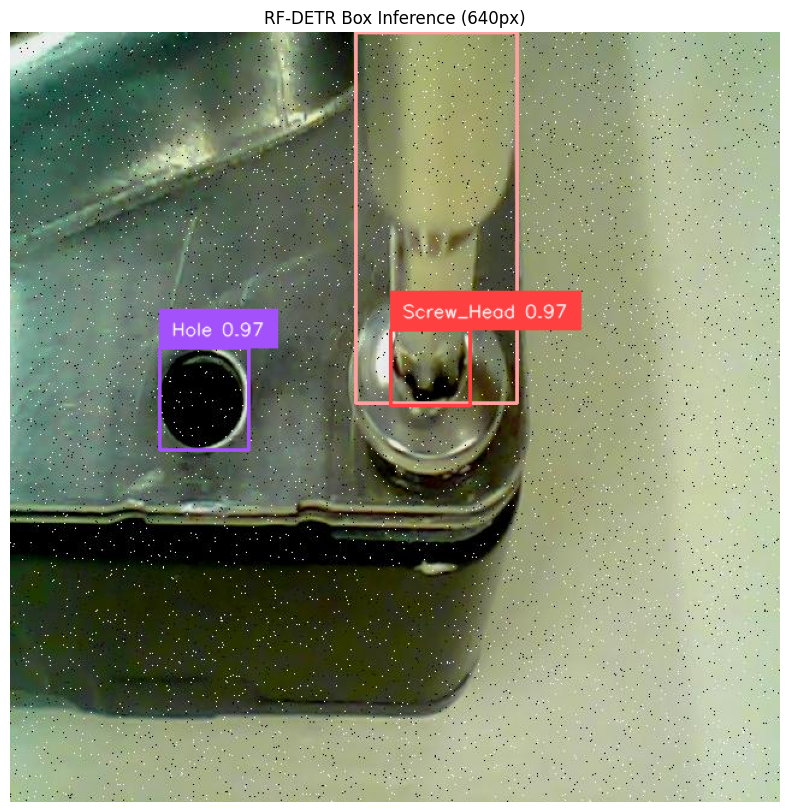

In [10]:
from PIL import Image
import numpy as np

# Load the BEST weights (Exponential Moving Average weights)
weights_path = os.path.join(RUN_DIR, "checkpoint_best_ema.pth")

# Re-initialize model with the trained weights
model = RFDETRSmall(pretrain_weights=weights_path, resolution=640)

# Grab a random test image
test_images_dir = os.path.join(OUTPUT_DIR, 'test', 'images')
test_img_path = os.path.join(test_images_dir, os.listdir(test_images_dir)[0])
pil_image = Image.open(test_img_path)

# Run Inference
detections = model.predict(pil_image, threshold=0.4)

# Convert PIL image to CV2 format for Supervision drawing
cv_image = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)

# Setup Annotators
box_annotator = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5, text_padding=10)

# Generate Labels with Confidence
labels = [
    f"{classes[class_id]} {confidence:.2f}"
    for class_id, confidence in zip(detections.class_id, detections.confidence)
]

# Apply Annotations
annotated_image = box_annotator.annotate(scene=cv_image.copy(), detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections, labels=labels)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("RF-DETR Box Inference (640px)")
plt.show()